In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 1:** Searching for contamination sources

I am tasked with detecting likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

- **Optimisation Goal**: Maximise
- **Input:** 2D array. The initial dataset contained 10 observations. 
    - Now the data set includes my 10 weeks of manual and model-driven queries, the dataset now contains 20 data points.

- **All time best:** 2.80e-06 at [0.472, 0.352] (Week 5)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 10 (Function 1)
X_w10_new_point = np.array([0.766420, 0.752405], dtype=np.float64)
Y_w10_new_point = np.array([4.6411490815692665e-25], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w10_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w10_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.378447   0.273576  ]
 [0.41043714 0.1475543 ]
 [0.472      0.332     ]
 [0.472361   0.351758  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.76642    0.752405  ]
 [0.799197   0.803213  ]
 [0.819277   0.694779  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  1.03307824e-046
  1.46776061e-046 -3.60606264e-003  2.53500115e-040  7.71087511e-016
 -5.11184814e-169  4.64114908e-025  4.75768881e-042 -1.84087865e-029
  3.34177101e-124  6.22985647e-048 -3.04056455e-090  0.00000000e+000]


## **Output Analysis**
- **Comparision:** Week 10 returned an output of 4.64e-25. 
    - While this is slightly better than last weeks value (1.84e-29), it is effectively zero and is still wose than the Week 5 best (2.8e-06).

- **Real-world implication:** A sensor returning zero at a distant point simply tells you the sourxe is not there, it doesn't really help locate it. 
    - The w9 directional result (stronger signal at x2 = 0.353 than x2 = 0.332) remains the most valuable data point for this function. 
    - The source is along the x1 = 0.472 vertical axis.

- **Model Clues and Future Exploration:** The strategy must return to methodical sampling along x1 = 0.472. 
    - A random query like w10 [0.767, 0.752] is wasted budget when we already know the singal exists only in a narrow corridor.
    - W11 will query directly at the w5 best [0.472, 0.352] to confirm wheether the signal is reproducible and to give the GP its strongest anchor point.

## **Bayesian Optimisation** 

- **Model**: Matern (nu=2.5) + WhiteKernel with Yeo-Johnson transformation.
    - No changes, the model is not the problem.

- **Key change**: Abandoning any form of a brad grid search. 
    - The Yeo-Johnson transformation remains essential to handle multi-order of magnitude output range.
        - Increasing `n_researts_optimizer` to 15 to ensure the kernel gets the best possible fit from the limited non-zero data.

- **Limitation**: With only two meaninful positive readings across 10 weeks, the GP's gradient estimate is still highly uncertain.
    - Even with a well-fitted kernel will hav wide confidence intervals.
    - The model is being used primarily to inform where uncertainty is lowest, not to predict the true function shape.

In [3]:
Y_clipped = np.clip(Y_updated, -1e10, None)
Y_transformed = power_transform(Y_clipped.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(
    length_scale=1.0,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    normalize_y=False)

model.fit(X_unique, Y_transformed)

Original Y: [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -4.58534168e-018
 -2.15924904e-054  1.82102900e-008  2.80463460e-006  1.03307824e-046
  1.46776061e-046 -3.60606264e-003  2.53500115e-040  7.71087511e-016
 -5.11184814e-169  4.64114908e-025  4.75768881e-042 -1.84087865e-029
  3.34177101e-124  6.22985647e-048 -3.04056455e-090  0.00000000e+000]
Transformed Y: [ 0.22608419  0.22608419  0.22608419  0.22608419  0.22608419  0.22648723
  0.28857749  0.22608419  0.22608419 -4.35849601  0.22608419  0.22608419
  0.22608419  0.22608419  0.22608419  0.22608419  0.22608419  0.22608419
  0.22608419  0.22608419]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",15
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- Due to the near-zero outputs observed across most of the domain, the Expected Improvement acquisition function became ineffective, as it relies on measurable improvement over the current best. 

- To address this, the strategy was shifted to a Upper Confidence Bound (UCB) framework with a high exploration parameter (κ=8) to prioritise uncertainty. 
    = Additionally, a distance-based weighting term was introduced to concentrate the search within a local trust region centred on the highest observed signal. 
    
- Candidate points were sampled from a Gaussian distribution around this region to improve efficiency and increase the likelihood of identifying the narrow optimum.

- **Limitations**: Gaussian Process models may still struggle with extremely sharp or discontinuous peaks, limiting predictive accuracy
    - Local sampling reduces global coverage, increasing the risk of missing alternative optima elsewhere in the domain.

In [4]:
def weighted_ucb(X, model, x_star, kappa=8, lam=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    # Upper Confidence Bound
    ucb = mu + kappa * sigma
    
    # Local weighting term
    distances = np.linalg.norm(X - x_star, axis=1).reshape(-1, 1)
    weights = np.exp(-(distances**2) / lam)
    
    return ucb * weights

x_best = np.array([0.472, 0.34])

N = 2000  # sample size
x_grid = np.random.normal(loc=x_best, scale=0.05, size=(N, 2))
x_grid = np.clip(x_grid, 0, 1)

ucb_values = weighted_ucb(x_grid, model, x_best)

best_idx = np.argmax(ucb_values)
next_query = x_grid[best_idx]

print(f'Strategic Week 11 Query (Function 1): {next_query[0]:.6f}-{next_query[1]:.6f}')

Strategic Week 11 Query (Function 1): 0.521101-0.340595


## **Visualisation**

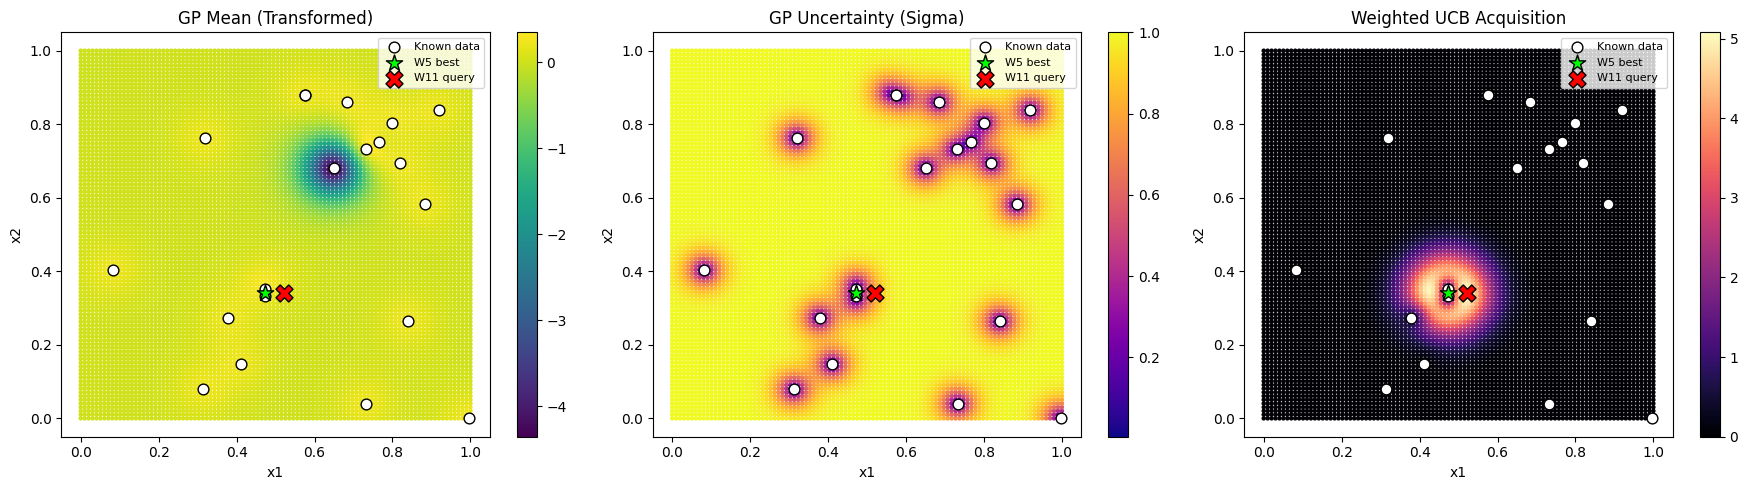

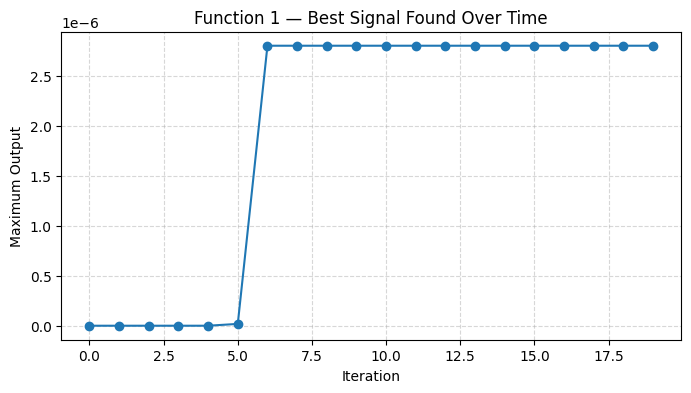

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1, x2)
x_plot = np.vstack([X1.ravel(), X2.ravel()]).T

titles = [
    'GP Mean (Transformed)',
    'GP Uncertainty (Sigma)',
    'Weighted UCB Acquisition'
]

mu_grid, sigma_grid = model.predict(x_plot, return_std=True)

# Ensure correct shapes
mu_grid = mu_grid.flatten()
sigma_grid = sigma_grid.flatten()
ucb_grid = weighted_ucb(x_plot, model, x_best).flatten()

surfaces = [mu_grid, sigma_grid, ucb_grid]
cmaps = ['viridis', 'plasma', 'magma']

for ax, surface, title, cmap in zip(axes, surfaces, titles, cmaps):
    
    sc = ax.scatter(
        x_plot[:, 0],
        x_plot[:, 1],
        c=surface,
        cmap=cmap,
        s=5
    )
    
    # Known points
    ax.scatter(
        X_unique[:, 0],
        X_unique[:, 1],
        c='white',
        edgecolors='black',
        s=60,
        label='Known data'
    )
    
    # Week 5 best
    ax.scatter(
        x_best[0],
        x_best[1],
        c='lime',
        edgecolors='black',
        s=150,
        marker='*',
        label='W5 best'
    )
    
    # Week 11 query
    ax.scatter(
        next_query[0],
        next_query[1],
        c='red',
        edgecolors='black',
        s=150,
        marker='X',
        label='W11 query'
    )
    
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# =========================
# 6. Progress plot
# =========================
running_max = np.maximum.accumulate(Y_updated)

plt.figure(figsize=(8, 4))
plt.plot(running_max, marker='o')
plt.title('Function 1 — Best Signal Found Over Time')
plt.xlabel('Iteration')
plt.ylabel('Maximum Output')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()